# Visibility graph

최근에 문득 [visibility graph](https://en.wikipedia.org/wiki/Visibility_graph)에 흥미가 생겼다.
구글링해보면 visibility graph의 예제와 응용에 대한 글은 쉽게 찾을 수 있었다.
하지만, visibility graph를 construction하는 방법에 대해서는 naive approach 외에는 제대로 정리되어 있는 내용을 찾을 수 없었다.
심지어 naive approach 조차도 알고리즘의 컨셉만을 설명할 뿐, 컨셉의 구현에 필요한 geometric operation에 대한 설명은 없었다.

조금 더 열심히 scholar를 뒤져보니 90년대에 visibility graph를 construction하는 효율적인 방법들이 많이 발표된 것 같다.
그래서, 이 포스팅에서는 visibility graph를 construction하는 효율적인 방법을 알아볼 것이다.
무엇이 더 좋아진 것인지 (빨라진 것인지) 알려면 naive approach에 대한 학습도 선행되어야 하므로 naive approach 역시 적지 않은 지면(화면...?)을 활용하여 설명한다.

이 포스팅에서 구현해 볼 "효율적인 방법"은 아래의 서적을 참고하였다.
저작권의 문제가 있을지 몰라 책의 링크는 첨부하지 않는다. 

- *De Berg, Mark. Computational geometry: algorithms and applications. Springer Science & Business Media, 2000.*

## I. Import useful packages

필자는 바퀴를 다시 발명하는 행위를 몹시 싫어한다.
그래서, 아래의 유용한 패키지들을 마구마구 사용할 것이다.
물론, 아래의 패키지를 사용할 때 구현이 "간편"해지는 것 뿐이지 알고리즘의 핵심 아이디어를 패키지의 기능으로 대충 대체하는 짓은 하지 않을 것이다. 

In [577]:
import networkx as nx
import numpy as np
import math
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import random
import shapely
from typing import Dict, List, Optional, Self, Tuple

EPS = 1e-3

## II. Define helper functions

Evaluation을 위해서 아래와 같이 helper function들을 준비했다.
이들은 polygon들과 시작점, 도착점으로 이루어진 world를 만들어 내며, 그 시각화를 돕는 function들이다.
주석 때문에 좀 길어보이지만, function name만 읽어보아도 하는 일이 자명하니 한번 쓱 읽고 넘기도록하자.

{: .note }
> - 이 포스팅에서 다루는 알고리즘은 inner hole이 없고, disjoint한 polygon들이 주어진 경우를 가정한다.
> - 그래서, world를 만들어 낼 때에 이러한 가정을 만족시키기 위한 코드들이 포함되어 있다.
> - 또한, 구현의 편의를 위해 시작점과 도착점이 장애물 (polygon) 들과 겹치지 않게 조치해두었다.

In [578]:
def generate_square(len: float) -> shapely.Polygon:
    """Returns a square polygon that its width and length are `len`.

    Args:
        len (float): Length of a square.

    Returns:
        shapely.Polygon: Generated square centered at origin.
    """
    return shapely.Polygon(
        (
            (len / 2, len / 2),
            (len / 2, -len / 2),
            (-len / 2, -len / 2),
            (-len / 2, len / 2),
            (len / 2, len / 2),
        )
    )

In [579]:
def rotate_and_translate(
    g: shapely.geometry, theta: float, x: float, y: float
) -> shapely.geometry:
    """Rotates and translates the given geometry `g`.

    Args:
        g (shapely.geometry): Geometry to be transformed.
        theta (float): Angle (degree) to rotate.
        x (float): Translation along x-axis.
        y (float): Translation along y-axis.

    Returns:
        shapely.geometry: Rotated and translated geometry.
    """
    return shapely.affinity.translate(shapely.affinity.rotate(g, theta), x, y)

In [580]:
def is_cw(ls: shapely.LineString, p: shapely.Point) -> bool:
    """Returns true if `p` is on the clockwise side of `ls`.

    Args:
        ls (shapely.LineString): Linestring.
        p (shapely.Point): Point.

    Returns:
        bool: True if clockwise
    """
    return (
        np.cross(
            np.array(
                [ls.coords[1][0] - ls.coords[0][0], ls.coords[1][1] - ls.coords[0][1]]
            ),
            np.array([p.x - ls.coords[0][0], p.y - ls.coords[0][1]]),
        )
        < 0
    )

In [581]:
def generate_world(config: Dict) -> Dict[str, shapely.Geometry]:
    """Generates a world depicted by the given `config`.

    Args:
        config (Dict): Configuration of the world.
        e.g.,
        {
            "seed"      : 0,
            "start"     : (0.0, 0.0),
            "goal"      : (100.0, 100.0),
            "obstacles" : {
                "number_of_squares" : 10,
                "length_range"      : (1.0, 5.0),
                "theta_range"       : (0.0, 360.0),
                "x_range"           : (10.0, 90.0),
                "y_range"           : (10.0, 90.0)
            }
        }

    Returns:
        Dict[str, shapely.Geometry]: Generated world.
        e.g.,
        {
            "start"     : shapely.Point,
            "goal"      : shapely.Point,
            "obstacles" : shapely.MultiPolygon,
        }
    """
    random.seed(config["seed"])
    squares = [
        rotate_and_translate(
            generate_square(random.uniform(*config["obstacles"]["length_range"])),
            random.uniform(*config["obstacles"]["theta_range"]),
            random.uniform(*config["obstacles"]["x_range"]),
            random.uniform(*config["obstacles"]["y_range"]),
        )
        for _ in range(config["obstacles"]["number_of_squares"])
    ]
    union = shapely.union_all(squares)
    if isinstance(union, shapely.Polygon):
        union = shapely.GeometryCollection((union))
    polygons = []
    for geom in union.geoms:
        polygons.append(shapely.Polygon(geom.exterior.coords))
    return {
        "start": shapely.Point((config["start"])),
        "goal": shapely.Point((config["goal"])),
        "obstacles": shapely.MultiPolygon(polygons),
    }

In [582]:
def draw_world(
    world: Dict[str, shapely.Geometry],
    graph: shapely.MultiLineString = shapely.MultiLineString(()),
):
    """Draws the given world and visibility graph.

    Args:
        world (Dict[str, shapely.Geometry]): World.
        e.g.,
        {
            "start"     : shapely.Point,
            "goal"      : shapely.Point,
            "obstacles" : shapely.MultiPolygon,
        }
        graph (shapely.MultiLineString): Edges of visibility graph.
    """
    fig, ax = plt.subplots()
    ax.plot(*world["start"].xy, "ro", label="start")
    ax.plot(*world["goal"].xy, "rx", label="goal")
    for obstacle in world["obstacles"].geoms:
        ax.add_patch(
            patches.Polygon(
                obstacle.exterior.coords,
                fc="green",
                lw=1.0,
                color="black",
                ls="--",
                alpha=0.5,
            )
        )
    for edge in graph.geoms:
        ax.plot(*edge.coords.xy, color="blue", lw=1.0)
    ax.set_aspect("equal")
    fig.tight_layout()
    plt.show()

## III. Generate an example world

정의해놓은 helper function들을 활용해서 앞으로의 구현에 사용할 example world를 만들어보자.
필자의 경우 아래와 같이 example world를 구성하였다.

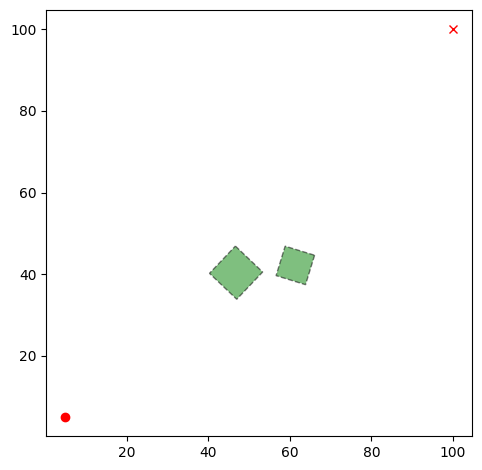

In [583]:
world = generate_world(
    {
        "seed": 0,
        "start": (5.0, 5.0),
        "goal": (100.0, 100.0),
        "obstacles": {
            "number_of_squares": 2,
            "length_range": (5.0, 10.0),
            "theta_range": (0.0, 180.0),
            "x_range": (30.0, 70.0),
            "y_range": (30.0, 70.0),
        },
    }
)
draw_world(world)

## IV. Implement naive algorithm

Naive approach를 **설명**하는 것은 비트, 전파, 광케이블 낭비이다.
다만, `if polygons.boundary.contains(ls) or ls.touches(polygons):` 절과 같이 naive approach 구현 시 필요한 geometric operation들이 단순화될 수 있음을 주목하자.
이 연산들은 대부분의 geometric library에서 지원하는 연산이므로 쉽게 대채할 수 있을 것이다.

In [584]:
def construct_visibility_graph_naively(
    world: Dict[str, shapely.Geometry]
) -> List[shapely.LineString]:
    """Constructs a visibility graph using a naive algorithm.

    Args:
        world (Dict[str, shapely.Geometry]): World.
        e.g.,
        {
            "start"     : shapely.Point,
            "goal"      : shapely.Point,
            "obstacles" : shapely.MultiPolygon,
        }

    Returns:
        List[shapely.LineString]: Edges of the generated visibility graph.
    """
    points = [world["start"], world["goal"]]
    polygons = world["obstacles"]
    for polygon in polygons.geoms:
        points.extend([shapely.Point(point) for point in polygon.exterior.coords[:-1]])

    graph = []
    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            ls = shapely.LineString((points[i], points[j]))
            if polygons.boundary.contains(ls) or ls.touches(polygons):
                graph.append(ls)

    return shapely.MultiLineString(graph)

구현한 naive approach를 미리 생성해둔 example world에 적용하면 아래와 같은 결과를 얻을 수 있다.
제대로 잘 구현이 되었음을 알 수 있다.

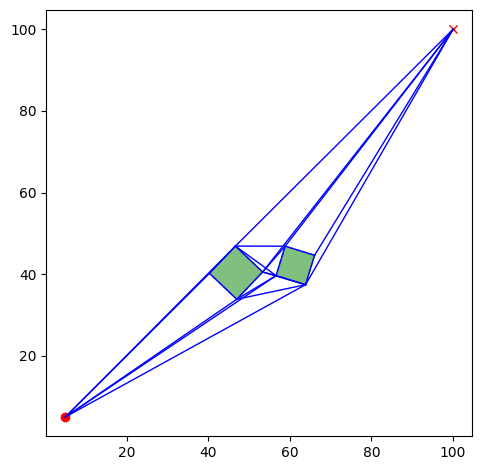

In [585]:
draw_world(world, construct_visibility_graph_naively(world))

## V. Lee's approach

이제 보다 효율적인 알고리즘에 알아보자.
필자는 이 알고리즘을 모두에 언급한 DeBerg의 책에서 발견하였다.
하지만, 히스토리를 살펴보니 이 알고리즘은 D.T Lee 씨의 [dissertation](https://www.proquest.com/openview/d5156a89232a691e5534a148eabc9dc7/1?pq-origsite=gscholar&cbl=18750&diss=y)에서 처음으로 제안되었다.

D.T Lee 씨께서는 이 알고리즘이 그닥 대단한 것은 아니라고 여기셨는지 그냥 맥 없이 휙 지나가는 챕터 정도로, 별 다른 설명이 없이 가볍게 다루었다.
~~이럴 때면 가끔씩 자괴감이...~~
별 다른 설명이 없었기에, 구현하기에도, 이해하기에도 상당히 난해했는데 필자는 그래도 종래에는 어떻게든 이해를 한 것 같다.
그래서, 이 포스팅에서도 필자가 이해한 순서대로 설명을 해보려한다.

D.T Lee 씨의 아이디어를 잘 이해하려면 알고리즘의 전체 구조를 top-down으로 살펴보는 것이 좋다.
적어도 필자는 이 편이 조금 더 이해가 수월했다.
효율적인 알고리즘의 얼개는 아래의 `construct_visibility_graph_efficiently`와 같다.

In [586]:
def construct_visibility_graph_efficiently(
    world: Dict[str, shapely.Geometry]
) -> List[shapely.LineString]:
    """Constructs a visibility graph using an efficient algorithm.
    This is a skeleton of the D.T Lee's algorithm.

    Args:
        world (Dict[str, shapely.Geometry]): World.
        e.g.,
        {
            "start"     : shapely.Point,
            "goal"      : shapely.Point,
            "obstacles" : shapely.MultiPolygon,
        }

    Returns:
        List[shapely.LineString]: Edges of the generated visibility graph.
    """
    graph = []
    polygons = world["obstacles"]
    graph.extend(construct_edges(world["start"], polygons).geoms)
    graph.extend(construct_edges(world["goal"], polygons).geoms)

    polygon_graph = build_polygon_graph(world["obstacles"])

    points = []
    for polygon in polygons.geoms:
        points.extend([shapely.Point(point) for point in polygon.exterior.coords[:-1]])

    for point in points:
        for q in get_visible_points(point, polygons, polygon_graph):
            graph.append(shapely.LineString((point, q)))

    return shapely.MultiLineString(graph)

`construct_visibility_graph_efficiently`에는 아래 세개 함수가 등장한다.

- `build_polygon_graph(polygons)`
  - 후술할 (효율적인) 알고리즘은 특정한 점에 연결된 다각형 변을 쉽게 조회할 수 있어야하는 등 주어진 다각형 꼭지점의 연결관계를 관리해주어야 한다.
  - 이것이 뭐 대단한 일이겠냐만, 필자의 경우 `netwrokx` 패키지를 사용하여 연결관계를 그래프로 관리하였다.
  - Visibility **graph**를 만들면서 단지 다각형 꼭지점 간의 연결관계를 나타내기 위하여 그래프를 사용하는 점이 독자에게 혼란을 줄까 걱정된다.
  - 그래도, (일단 내 블로그는 독자도 없을뿐더러 ㅜㅜ) 이것을 사용함으로서 얻는 이득이 더 크다고 판단하여 결정하였으니 독자의 너른 이해를 바란다.
- `construct_edges(p, polygons)`
  - 점 `p`에서부터 다각형 집합 `polygons`에 대해 보이는 꼭지점을 연결하는 그래프 간선들을 반횐한다.
  - 이것은 Lee's approach에서 다루고 있는 내용이 **아니다** (D.T Lee 씨는 시작점 및 도착점이 없는 문제를 풀었음).
  - 이 부분은 단지 필자가 start, goal을 다루기 위하여 추가한 코드이며 naive approach와 동일한 방법을 사용하여 start, goal로부터 보이는 다각형 꼭지점을 연결한다.
- `get_visible_points(p, polygons, polygon_graph)`: 점 `p`에서 다각형 집합 `polygons`에 대해 보이는 꼭지점들의 목록을 반환한다.
  - 이 함수가 바로 D.T Lee씨 논문의 main contribution 이며, 이 과정의 복잡도가 `O(NlgN)`이 되게 된다.

### V.1. `build_polygon_graph(polygons)`

이 함수는 `networkx` 패키지를 사용해서 아래와 같이 간단히 구현할 수 있다.

In [587]:
def build_polygon_graph(polygons: shapely.MultiPolygon) -> nx.Graph:
    """Builds a graph of which the vertices are points, and the edges are the sides.

    Args:
        polygons (shapely.MultiPolygon): Obstacles.

    Returns:
        nx.Graph: A graph representing the polygons.
    """
    id = 0
    graph = nx.Graph()
    for polygon in polygons.geoms:
        offset = id
        for i in range(len(polygon.exterior.coords) - 1):
            graph.add_node(id, id=id, coord=shapely.Point(polygon.exterior.coords[i]))
            id += 1
        for i in range(len(polygon.exterior.coords) - 2):
            graph.add_edge(offset + i, offset + i + 1)
        graph.add_edge(offset, offset + len(polygon.exterior.coords) - 2)
    return graph

### V.2. `construct_edges(p, polygons)`

앞서 말하였듯 `construct_edges(p, polygons)`는 딱히 언급할만한 내용이 없다 (naive approach와 크게 다르지 않으므로).

In [588]:
def construct_edges(
    p: shapely.Point, polygons: shapely.MultiPolygon
) -> shapely.MultiLineString:
    """Returns visibility graph edges spanning from `p`.

    Args:
        p (shapely.Point): Start or goal points.
        polygons (shapely.MultiPolygon): Obstacles.

    Returns:ß
        shapely.MultiLineString: Edges of the generated visibility graph.
    """
    graph = []
    for polygon in polygons.geoms:
        for q in polygon.exterior.coords[:-1]:
            ls = shapely.LineString((p, q))
            if ls.touches(polygons):
                graph.append(ls)
    return shapely.MultiLineString(graph)

### V.3. `get_visible_points(p, polygons)`

이제 `get_visible_points(p, polygons)`의 효율적인 구현에 대해서 살펴보자.
이 함수의 구현에 사용되는 D.T Lee 씨의 아이디어는 꽤나 복잡하기 때문에 몇 단계로 나누어 설명할 것 이다.

#### V.3.1. D.T Lee sweeps the plane using a half line in clockwise order

D.T Lee 는 반직선 (i.e. sweep line) 을 통해 평면을 시계 방향으로 sweep한다.
아래 예제는 이것이 무슨 말인지를 보여주고 있다.
`sweep-{i}` 따위로 표현되고 이있는 반직선들이 바로 그것인데, 최초의 수평 방향 (positive-x 방향으로 뻗는) 반직선부터 시작하여 시계 방향으로 평면을 훑는다.
최초의 sweep line을 제외하고는 모두 주어진 한 꼭지점 `p`로부터 다른 다각형의 꼭지점을 잇는 직선들이 sweep line으로 사용된다.

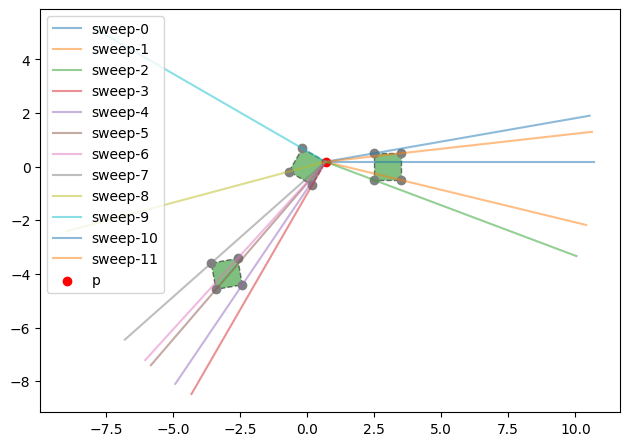

In [589]:
# DO NOT COPY THIS.
def scan_example(polygons):
    def my_atan2(p: shapely.Point, q: shapely.Point) -> float:
        theta = math.atan2(q.y - p.y, q.x - p.x)
        theta = -theta if theta < 0 else 2 * math.pi - theta
        return theta

    pts = []
    for polygon in polygons.geoms:
        pts.extend([shapely.Point(pt) for pt in polygon.exterior.coords[:-1]])
    p = pts[1]
    pts.sort(
        key=lambda q: (
            my_atan2(p, q),
            math.hypot(q.x - p.x, q.y - p.y),
        )
    )

    fig, ax = plt.subplots()
    for obstacle in polygons.geoms:
        ax.add_patch(
            patches.Polygon(
                obstacle.exterior.coords,
                fc="green",
                lw=1.0,
                color="black",
                ls="--",
                alpha=0.5,
            )
        )
    plt.plot([p.x, p.x + 10], [p.y, p.y], label="sweep-0", alpha=0.5)
    for i, q in enumerate(pts):
        if p == q:
            continue
        src = np.array([p.x, p.y])
        dst = np.array([q.x, q.y])
        dst = src + 10 * ((dst - src) / np.linalg.norm(dst - src))
        plt.plot([src[0], dst[0]], [src[1], dst[1]], label=f"sweep-{i+1}", alpha=0.5)
        plt.scatter(q.x, q.y, color="gray")

    plt.scatter(p.x, p.y, color="red", label="p")
    ax.set_aspect("equal")
    fig.tight_layout()
    plt.legend()
    plt.show()


fig_polygons = shapely.MultiPolygon(
    (
        rotate_and_translate(
            shapely.Polygon(((0.5, 0.5), (0.5, -0.5), (-0.5, -0.5), (-0.5, 0.5))),
            60,
            0,
            0,
        ),
        rotate_and_translate(
            shapely.Polygon(((0.5, 0.5), (0.5, -0.5), (-0.5, -0.5), (-0.5, 0.5))),
            0,
            3,
            0,
        ),
        rotate_and_translate(
            shapely.Polygon(((0.5, 0.5), (0.5, -0.5), (-0.5, -0.5), (-0.5, 0.5))),
            10,
            -3,
            -4,
        ),
    )
)

scan_example(fig_polygons)

#### V.3.2. D.T Lee manages `candidate_sides`

D.T Lee 씨는 위에서 밝힌 방법대로 평면을 sweep하며 `candidate_sides`라는 자료구조를 관리한다.
이 자료구조는 점 `p`에서 다각형 집합 `polygons`에 대해 보이는 꼭지점을 조사함에 있어 확인해 볼 가치가 있는 다각형의 변들을 의미한다.
반대로 이야기하면, `candidate_sides`에 속하지 않는 다각형의 변들은 확인해볼 필요가 없다는 것이다.
대체 뭘 어떻게 관리하기에 이러한 마법이 가능한 것인지 방법을 알아보도록 하자.

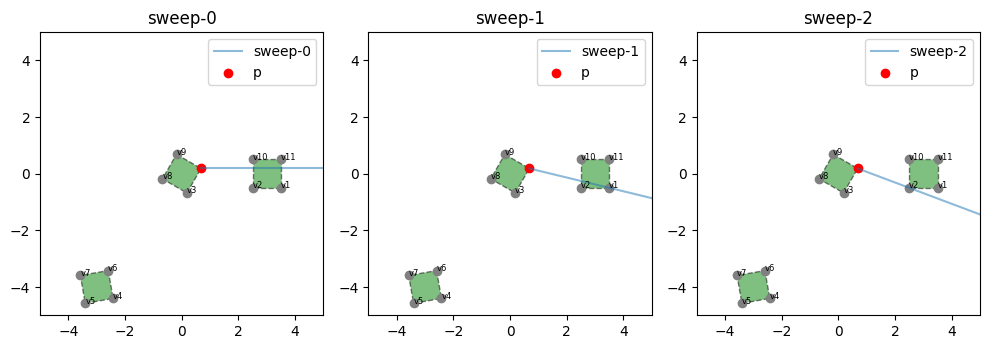

In [590]:
# DO NOT COPT THIS CODE BLOCK.
def candidate_sides_example(polygons):
    def my_atan2(p: shapely.Point, q: shapely.Point) -> float:
        theta = math.atan2(q.y - p.y, q.x - p.x)
        theta = -theta if theta < 0 else 2 * math.pi - theta
        return theta

    pts = []
    for polygon in polygons.geoms:
        pts.extend([shapely.Point(pt) for pt in polygon.exterior.coords[:-1]])
    p = pts[1]
    pts.sort(
        key=lambda q: (
            my_atan2(p, q),
            math.hypot(q.x - p.x, q.y - p.y),
        )
    )

    fig, ax = plt.subplots(1, 3, figsize=(10, 5))
    for obstacle in polygons.geoms:
        for i in range(3):
            ax[i].add_patch(
                patches.Polygon(
                    obstacle.exterior.coords,
                    fc="green",
                    lw=1.0,
                    color="black",
                    ls="--",
                    alpha=0.5,
                )
            )
    ax[0].plot([p.x, p.x + 10], [p.y, p.y], label="sweep-0", alpha=0.5)
    for i, q in enumerate(pts):
        if p == q:
            continue
        if i < 2:
            src = np.array([p.x, p.y])
            dst = np.array([q.x, q.y])
            dst = src + 10 * ((dst - src) / np.linalg.norm(dst - src))
            ax[i + 1].plot(
                [src[0], dst[0]], [src[1], dst[1]], label=f"sweep-{i+1}", alpha=0.5
            )
        for k in range(3):
            ax[k].scatter(q.x, q.y, color="gray")
            ax[k].text(q.x, q.y, f"v{i + 1}", fontsize=6)

    for i in range(3):
        ax[i].scatter(p.x, p.y, color="red", label="p")
        ax[i].set_aspect("equal")
        ax[i].set_xlim([-5, 5])
        ax[i].set_ylim([-5, 5])
        ax[i].legend()
        ax[i].set_title(f"sweep-{i}")
    fig.tight_layout()
    plt.show()


candidate_sides_example(fig_polygons)

위의 그림은 첫번째, 두번째, 그리고 세번째 sweeping을 보이고 있다.
`sweep-0`을 시작하기 전 최초의 상태에서는 `candidate_sides`는 비어있다.
이제 차례로 3번의 sweeping을 살펴보도록 하자.

- `sweep-0`를 살펴보자.
  - `sweep-0`은 일종의 initial condition으로 점 `p`에서 positive-x 방향으로 뻗는 sweep line을 사용한다.
  - 첫번째 sweep은 일종의 initial condition으로 볼 수 있는데, 아래의 과정을 통해 `candidate_sides`를 갱신해주면 된다.
  - sweep line과 교차하는 다각형의 변들을 찾아 `candidate_sides`에 추가해준다.
  - 단, sweep line과 다각형의 변이 변의 끝점에서 교차하는 경우에는 추가하지 않는다.
  - 그림의 예제에서는 `v2-v10`, `v1-v11` 이 추가될 것이다.

- `sweep-1`을 살펴보자.
  - `sweep-1`은 점 `p`와 `v1`을 잇는 sweep line을 사용한다.
  - `candidate_sides`에 속한 변들과 sweep line이 `v1`이 아닌 곳에서 교점을 갖는지 확인한다.
  - 교점이 있다면, `p`에서 `v1`은 보이지 않는다 (반대로 교점이 없다면 보이는 것임).
  - 그림의 예제에서는 sweep line이 `candidate_sides`에 속한 `v2-v10`과 교점을 갖으므로 `p`에서 `v1`은 보이지 않는다.
  - 교점의 확인이 끝나면, `v1`을 포함하는 두 변을 조사한다.
    - 두개의 변 중 sweep line을 기준으로 반시계 방향에 위치하는 변은 `candidate_sides`에서 삭제한다.
    - 두개의 변 중 sweep line을 기준으로 시계 방향에 위치하는 변은 `candidate_sides`에서 추가한다.
  - 그림의 예제에서는 `v1-v2`가 `candidate_sides`에 추가되고, `v1-v11` 이 `candidate_sides`에서 삭제된다.

- `sweep-2`을 살펴보자 (`sweep-1`과 동일한 과정이니 결과만 기술함).
  - `sweep-2`은 점 `p`와 `v2`을 잇는 sweep line을 사용한다.
  - `candidate_sides`에 속한 변들과 sweep line이 `v2`가 아닌 곳에서 교점을 갖는지 확인한다.
  - 그림의 예제에서는 sweep line과 `candidate_sides`에 속한 변들과의 교점은 모두 `v2`이므로 `p`에서 `v2`가 보인다.
  - 또한, `v2`에 인접한 두개의 변을 조사하는 과정에서 `v1-v2`, `v2-v10`이 `candidate_edges`에서 삭제된다 (추가되는 변은 없음).

#### V.3.3. D.T Lee implements `candidate_sides` as a binary tree

V.3.2 에서 관찰할 수 있는 흥미로운 사실이 있다.
그것은 sweep line과 교차하는 다각형의 변을 `candidate_sides`에서 찾을 때 굳이 모든 변들을 다 검사할 필요가 없다는 점이다.

만약 `candidate_sides`에 있는 변들이 **직전** sweep line에서의 교점 순서대로 사전에 정렬되어 있다고 가정해보자.
"교점 순서대로" 라는 표현이 조금 혼란스러울 것 같다.
이는 단순히 sweep line 상에서 교점까지의 거리가 보다 가까운 변을 보다 앞에 저장한다는 의미이다.
예를 들어, `sweep-0`에서 `v2-v10`, `v1-v11` 중 누가 더 sweep line과 먼저 교차하는가?
`v2-v10`이므로 `candidate_sides`에는 `v2-v10`을 `v1-v11`보다 앞에 저장한다.

이제 `sweep-1`으로 가보자.
다각형의 변들은 서로 교차 (꼭지점에서 만나는 것은 제외) 하지 않으므로 `sweep-0` 에서 만들어 놓은 순서는 세로운 변을 추가하기 전까지 유지될 것이다.
즉, 교점의 위치는 바뀌겠지만 교점 간의 위상(..?)은 변경되지 않는다는 이야기이다.
따라서, `sweep-1`에서 `v1`의 visibility를 판단할 떄는 sweep line과 `v2-v10` (`candidate_sides`의 가장 앞 원소)의 교차 여부만을 확인해주면 된다.
이는 앞에 저장되어 있는 다각형의 변과는 교점을 갖지 않았는데, 뒤에 저장되어 있는 다각형의 변과는 교점을 갖는 것은 불가능하기 때문이다.

여기까지 읽으면 스멀스멀 감이온다.
`candidate_sides`는 binary tree 형태로 관리하기 몹시 적절한 자료구조이다!
다만, 각 노드가 고정된 key 값을 갖지 않고, sweep line 상 교점의 위상을 기준으로 정렬되므로 구현이 은근히 까다롭다.
필자는 이를 아래와 같이 구현하였다.

In [591]:
class Side:
    """A class representing a side of a polygon."""

    def __init__(self, src_id: int, dst_id: int, polygon_graph: nx.Graph):
        """C'tor.

        Args:
            src_id (int): ID of source vertex.
            dst_id (int): ID of destination vertex.
            polygon_graph (nx.Graph): A graph representing polygons.
        """
        if src_id > dst_id:
            self.__init__(dst_id, src_id, polygon_graph)
            return
        self.src_id = src_id
        self.dst_id = dst_id
        self.side = shapely.LineString(
            (polygon_graph.nodes[src_id]["coord"], polygon_graph.nodes[dst_id]["coord"])
        )
        self.left = None
        self.right = None

    def is_equal(self, rhs: Self) -> bool:
        """Returns whether the `rhs` is equals to `self`.

        Args:
            rhs (Self): A side.

        Returns:
            bool: True if `self` and `rhs` are equal.
        """
        return self.src_id == rhs.src_id and self.dst_id == rhs.dst_id

    def is_less_equal(self, sweep_line: shapely.LineString, rhs: Self) -> bool:
        """Returns whether `self <= rhs` on the given `sweep_line`.

        Args:
            sweep_line (shapely.LineString): A sweep line.
            rhs (Self): A side.

        Returns:
            bool: Whether `self <= rhs` on the given `sweep_line`.
        """

        def get_intersection(
            side: shapely.LineString, sweep_line: shapely.LineString
        ) -> Tuple[Optional[float], Optional[shapely.Point]]:
            p = sweep_line.coords[0]
            min_length = None
            min_intersection = None
            for intersect in sweep_line.intersection(side, grid_size=EPS).coords:
                length = np.hypot(intersect[0] - p[0], intersect[1] - p[1])
                if min_length is None or length < min_length:
                    min_length = length
                    min_intersection = shapely.Point(intersect)
            return min_length, min_intersection

        length_self, intersection_self = get_intersection(self.side, sweep_line)
        length_rhs, intersection_rhs = get_intersection(rhs.side, sweep_line)

        if abs(length_self - length_rhs) > EPS:
            return length_self <= length_rhs

        self_end = (
            self.side.coords[0]
            if self.side.coords[1] == intersection_self.coords
            else self.side.coords[1]
        )
        rhs_end = (
            rhs.side.coords[0]
            if rhs.side.coords[1] == intersection_rhs.coords
            else rhs.side.coords[1]
        )

        return is_cw(
            shapely.LineString((intersection_rhs, rhs_end)), shapely.Point(self_end)
        )

In [592]:
class CandidateSides:
    """A class for candidate sides."""

    def __init__(self):
        """C'tor."""
        self.root = None

    def get_min(self) -> Optional[Side]:
        """Gets the minimum side.

        Returns:
            Side: The minimum side.
        """
        return self._get_min(self.root)

    def _get_min(self, root: Optional[Side]) -> Optional[Side]:
        """Gets the minimum side from a tree rooted at `root`.

        Args:
            root (Optional[Side]): A root.

        Returns:
            Optional[Side]: The minimum side.
        """
        if root is not None and root.left is not None:
            return self._get_min(root.left)
        else:
            return root

    def get_max(self) -> Optional[Side]:
        """Gets the maximum side.

        Returns:
            Side: The maximum side.
        """
        return self._get_max(self.root)

    def _get_max(self, root: Optional[Side]) -> Optional[Side]:
        """Gets the maximum side from a tree rooted at `root`.

        Args:
            root (Optional[Side]): A root.

        Returns:
            Optional[Side]: The maximum side.
        """
        if root is not None and root.right is not None:
            return self._get_max(root.right)
        else:
            return root

    def insert(self, sweep_line: shapely.LineString, side: Side) -> Side:
        """Inserts a side to the tree.

        Args:
            sweep_line (shapely.LineString): A sweep line.
            side (Side): A side to insert.

        Returns:
            Side: A root of inserted tree.
        """
        self.root = self._insert(sweep_line, self.root, side)
        return self.root

    def _insert(
        self, sweep_line: shapely.LineString, root: Optional[Side], side: Side
    ) -> Side:
        """Inserts a side to the tree.

        Args:
            sweep_line (shapely.LineString): A sweep line.
            root (Optional[Side]): A root.
            side (Side): A side to insert.

        Returns:
            Side: A root of inserted tree.
        """
        if root is None:
            root = side
        elif side.is_less_equal(sweep_line, root):
            root.left = self._insert(sweep_line, root.left, side)
        else:
            root.right = self._insert(sweep_line, root.right, side)
        return root

    def delete(self, sweep_line: shapely.LineString, side: Side) -> Optional[Side]:
        """Deletes a side from the tree.

        Args:
            sweep_line (shapely.LineString): A sweep line.
            side (Side): Side to delete.

        Returns:
            Optional[Side]: A root of deleted tree.
        """
        self.root = self._delete(sweep_line, self.root, side)
        return self.root

    def _delete(
        self, sweep_line: shapely.LineString, root: Optional[Side], side: Side
    ) -> Optional[Side]:
        """Deletes a side from the tree.

        Args:
            sweep_line (shapely.LineString): A sweep line.
            root (Optional[Side]): A root.
            side (Side): Side to delete.

        Returns:
            Optional[Side]: A root of deleted tree.
        """
        if root is None:
            return None
        elif root.is_equal(side):
            if root.left is None:
                return root.right
            elif root.right is None:
                return root.left
            else:
                max_side = self._get_max(root.left)
                root.src_id = max_side.src_id
                root.dst_id = max_side.dst_id
                root.side = max_side.side
                root.left = self._delete(sweep_line, root.left, max_side)
                return root
        elif side.is_less_equal(sweep_line, root):
            root.left = self._delete(sweep_line, root.left, side)
            return root
        else:
            root.right = self._delete(sweep_line, root.right, side)
            return root

    def traverse(self):
        """Inorder traverse."""
        self._traverse(self.root)

    def _traverse(self, root: Optional[Side], level: int = 0):
        """Inorder traverse of the tree rooted at `root`.

        Args:
            root (Optional[Side]): A root.
            level (int): Level of the root.
        """
        depth = ""
        for _ in range(level + 3):
            depth += "\t"
        if root is None:
            print(depth + "NULL")
            return
        self._traverse(root.left, level + 1)
        print(f"{depth}: {root.src_id} -> {root.dst_id}")
        self._traverse(root.right, level + 1)

#### V.3.4. Implement `get_visible_points(p, polygons, polygon_graph)`

이전 챕터들을 통해서, (1) D.T Lee 씨의 알고리즘에 대한 아이디어를 설명하였고, (2) 핵심이 되는 이진트리 자료구조를 구현하였다.
이제 모든 준비물(..?)이 모였으니 `get_visible_points(p, polygons)`를 구현해보자.

In [593]:
def get_visible_points(
    p: shapely.Point, polygons: shapely.MultiPolygon, polygon_graph: nx.Graph
) -> shapely.MultiPoint:
    """Returns points that are visible from `p`.

    Args:
        p (shapely.Point): A point.
        polygons (shapely.MultiPolygon): Obstacles.
        polygon_graph (nx.Graph): A polygon graph.

    Returns:
        shapely.MultiPoint: Visible points.
    """

    def my_atan2(p: shapely.Point, q: shapely.Point) -> float:
        theta = math.atan2(q.y - p.y, q.x - p.x)
        theta = -theta if theta <= 0 else 2 * math.pi - theta
        return theta

    # Sort vertices by clockwise order.
    nodes = []
    for n in polygon_graph.nodes:
        if p != polygon_graph.nodes[n]["coord"]:
            nodes.append(polygon_graph.nodes[n])
        else:
            print(f"DEBUG: SWEEP_FROM: {n}")
    nodes.sort(
        key=lambda q: (
            my_atan2(p, q["coord"]),
            math.hypot(q["coord"].x - p.x, q["coord"].y - p.y),
        )
    )

    def make_sweep_line(
        p: shapely.Point, q: shapely.Point, length: float = 1e3
    ) -> shapely.LineString:
        dir = np.array([q.x - p.x, q.y - p.y])
        dir *= length / np.linalg.norm(dir)
        return shapely.LineString((p, (p.x + dir[0], p.y + dir[1])))

    # Plane sweep.
    candidates = CandidateSides()

    # Initial sweep (positive x-axis direction).
    sweep_line = make_sweep_line(p, shapely.Point(p.x + 1, p.y))
    for src_id, dst_id in polygon_graph.edges:
        src = polygon_graph.nodes[src_id]["coord"]
        dst = polygon_graph.nodes[dst_id]["coord"]
        ls = shapely.LineString((src, dst))
        if sweep_line.crosses(ls):
            candidates.insert(sweep_line, Side(src_id, dst_id, polygon_graph))

    # Sweep in the clockwise order.
    visible_points = []
    for node in nodes:
        print(f"DEBUG: SWEEP_TO: {node['id']}")
        candidates.traverse()  # DEBUG
        min_side = candidates.get_min()
        sweep_line = make_sweep_line(p, node["coord"])
        if min_side is None:
            visible_points.append(node["coord"])
        else:
            intersections = sweep_line.intersection(min_side.side, grid_size=EPS).coords
            if len(intersections) == 0 or (
                len(intersections) == 1
                and node["coord"] == shapely.Point(intersections[0])
            ):
                visible_points.append(node["coord"])
        for neighbor in polygon_graph.neighbors(node["id"]):
            side = Side(node["id"], polygon_graph.nodes[neighbor]["id"], polygon_graph)
            if is_cw(sweep_line, polygon_graph.nodes[neighbor]["coord"]):
                print(f"DEBUG: INSERT: {node['id']} -> {neighbor}")
                candidates.insert(sweep_line, side)
            else:
                print(f"DEBUG: DELETE: {node['id']} -> {neighbor}")
                candidates.delete(sweep_line, side)

    return visible_points

DEBUG: SWEEP_FROM: 0
DEBUG: SWEEP_TO: 7
			NULL
DEBUG: INSERT: 7 -> 6
DEBUG: INSERT: 7 -> 4
DEBUG: SWEEP_TO: 4
				NULL
			: 6 -> 7
					NULL
				: 4 -> 7
					NULL
DEBUG: INSERT: 4 -> 5
DEBUG: DELETE: 4 -> 7
DEBUG: SWEEP_TO: 5
				NULL
			: 6 -> 7
					NULL
				: 4 -> 5
					NULL
DEBUG: DELETE: 5 -> 4
DEBUG: INSERT: 5 -> 6
DEBUG: SWEEP_TO: 6
				NULL
			: 6 -> 7
					NULL
				: 5 -> 6
					NULL
DEBUG: DELETE: 6 -> 5
DEBUG: DELETE: 6 -> 7
DEBUG: SWEEP_TO: 1
				NULL
			: 5 -> 6
				NULL
DEBUG: DELETE: 1 -> 0


TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

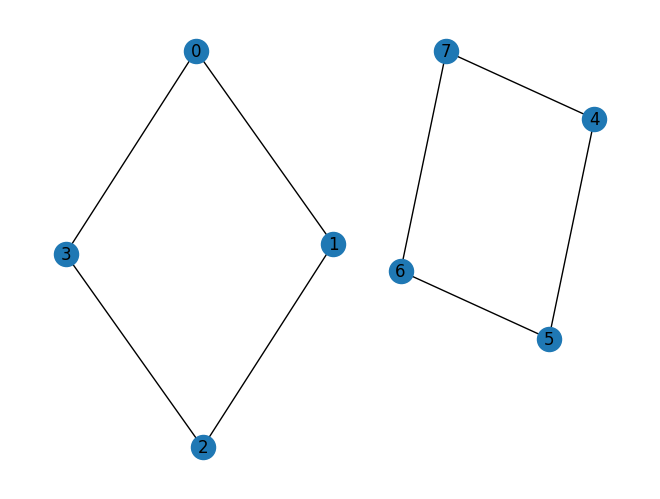

In [594]:
polygon_graph = build_polygon_graph(world["obstacles"])
# Draw with position coords.
nx.draw(
    polygon_graph,
    pos={
        n: (polygon_graph.nodes[n]["coord"].x, polygon_graph.nodes[n]["coord"].y)
        for n in polygon_graph.nodes
    },
    with_labels=True,
)

construct_visibility_graph_efficiently(world)